Uploading the file:

Loading the dataset:

In [ ]:
import pandas as pd

data = pd.read_csv("ai_job_dataset.csv")
data.head()


,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics


Basic Dataset Inspection:
  Shape of data:

In [ ]:
data.shape


(15000, 19)

This is done because to know the number of rows and columns

Column names:

In [ ]:
data.columns


Index(['job_id', 'job_title', 'salary_usd', 'salary_currency',
       'experience_level', 'employment_type', 'company_location',
       'company_size', 'employee_residence', 'remote_ratio', 'required_skills',
       'education_required', 'years_experience', 'industry', 'posting_date',
       'application_deadline', 'job_description_length', 'benefits_score',
       'company_name'],
      dtype='object')

Data types:

In [ ]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   job_id                  15000 non-null  object 
 1   job_title               15000 non-null  object 
 2   salary_usd              15000 non-null  int64  
 3   salary_currency         15000 non-null  object 
 4   experience_level        15000 non-null  object 
 5   employment_type         15000 non-null  object 
 6   company_location        15000 non-null  object 
 7   company_size            15000 non-null  object 
 8   employee_residence      15000 non-null  object 
 9   remote_ratio            15000 non-null  int64  
 10  required_skills         15000 non-null  object 
 11  education_required      15000 non-null  object 
 12  years_experience        15000 non-null  int64  
 13  industry                15000 non-null  object 
 14  posting_date            15000 non-null

This helps me understand the,

Numeric columns

Categorical columns

Unnecessary columns

Remove Unnecessary Columns:

In [ ]:
drop_cols = [
    'job_id',
    'company_name',
    'posting_date',
    'application_deadline',
    'required_skills',
    'salary_currency'
]

data = data.drop(columns=drop_cols)


These columns do not help salary prediction and it is removed

Handle Missing Values:

In [ ]:
data.isnull().sum()


,0
job_title,0
salary_usd,0
experience_level,0
employment_type,0
company_location,0
company_size,0
employee_residence,0
remote_ratio,0
education_required,0
years_experience,0


In [ ]:
# Numeric columns → fill with median
num_cols = data.select_dtypes(include=['int64', 'float64']).columns
data[num_cols] = data[num_cols].fillna(data[num_cols].median())

# Categorical columns → fill with mode
cat_cols = data.select_dtypes(include=['object']).columns
for col in cat_cols:
    data[col] = data[col].fillna(data[col].mode()[0])


This Handled them safely

Explanation:

 Median avoids outliers

Mode keeps category consistency

Separating Features & Target:

Target

In [ ]:
y = data['salary_usd']


Features:

In [ ]:
X = data.drop(columns=['salary_usd'])


Encoding Categorical Features:

In [ ]:
X = pd.get_dummies(X, drop_first=True)


Converts text → numbers

 Avoids dummy variable trap


Feature Scaling:

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


Scaling is REQUIRED because:

Ridge & Lasso penalize large values

Features must be on same scale

Training Testing and Spliting

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


PREPROCESSING COMPLETED and

Data is Cleaned

Encoded categorical variables

Scaled features

Train/test split ready

In [ ]:
X_train, X_test, y_train, y_test


(array([[-1.21248946, -0.76695274,  0.19212594, ..., -0.26883279,
         -0.26683146,  3.74768401],
        [-1.21248946, -0.22598165, -0.39283395, ..., -0.26883279,
         -0.26683146, -0.26683146],
        [-1.21248946, -1.12760013, -0.26959314, ..., -0.26883279,
         -0.26683146, -0.26683146],
        ...,
        [-1.21248946, -0.94727643,  0.56705572, ..., -0.26883279,
         -0.26683146, -0.26683146],
        [ 0.01265988,  0.31498943,  0.31363096, ..., -0.26883279,
         -0.26683146, -0.26683146],
        [-1.21248946, -0.94727643,  0.03764098, ..., -0.26883279,
         -0.26683146, -0.26683146]]),
 array([[ 1.23780922,  0.49531313,  0.86213934, ..., -0.26883279,
         -0.26683146, -0.26683146],
        [ 0.01265988,  0.49531313,  1.39328986, ..., -0.26883279,
         -0.26683146, -0.26683146],
        [ 1.23780922,  0.49531313, -1.5662253 , ..., -0.26883279,
         -0.26683146, -0.26683146],
        ...,
        [-1.21248946,  0.31498943, -0.72610486, ..., -

Linear Regression:

In [ ]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)


Ridge Regression:

In [ ]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_test)


It Handles multicollinearity

And it Prevents overfitting

Lasso Regression:

In [ ]:
from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=0.01)
lasso_model.fit(X_train, y_train)

lasso_pred = lasso_model.predict(X_test)


Performs feature selection and

It Can drop less important features

Evaluation & Comparision of Models:

R² Score Comparison:

In [ ]:
from sklearn.metrics import r2_score

print("Linear Regression R²:", r2_score(y_test, linear_pred))
print("Ridge Regression R²:", r2_score(y_test, ridge_pred))
print("Lasso Regression R²:", r2_score(y_test, lasso_pred))


Linear Regression R²: 0.8522669815238053
Ridge Regression R²: 0.8522676063870325
Lasso Regression R²: 0.8522670593503392


Higher R^2 = Better model

R^2 is the Goodness of Fit and it determines the goodness of the model it is one of the evaluation metrics

Model Comparison Plot:

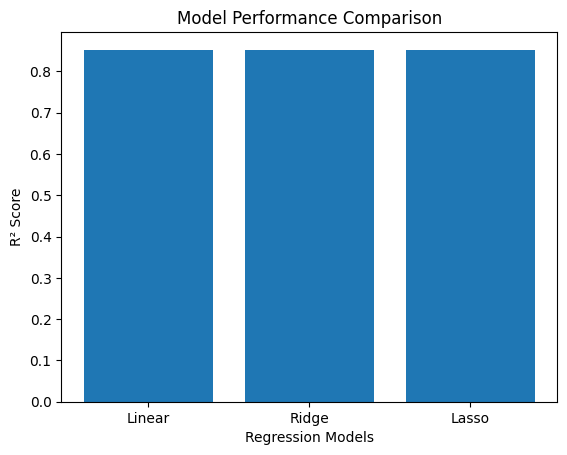

In [ ]:
import matplotlib.pyplot as plt

models = ['Linear', 'Ridge', 'Lasso']
scores = [
    r2_score(y_test, linear_pred),
    r2_score(y_test, ridge_pred),
    r2_score(y_test, lasso_pred)
]

plt.bar(models, scores)
plt.xlabel("Regression Models")
plt.ylabel("R² Score")
plt.title("Model Performance Comparison")
plt.show()


Selecting the Best Model:

In [ ]:
best_model = max(
    [('Linear', linear_model), ('Ridge', ridge_model), ('Lasso', lasso_model)],
    key=lambda x: x[1].score(X_test, y_test)
)

print("Best Performing Model:", best_model[0])


Best Performing Model: Ridge


Ridge Regression performed best because it handles multiple correlated features effectively.

Total number of features:

In [ ]:
len(X.columns)


86